In [2]:
#pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [68]:
# ── Time Series notebook — setup & load MBA handoff ────────────────────────
import pickle, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

with open('mba_handoff.pkl', 'rb') as _f:
    _h = pickle.load(_f)

df_units          = _h['df_units']
df_used_market    = _h['df_used_market']
name_map          = _h['name_map']
segmentation_data = _h['segmentation_data']
success_stories   = _h['success_stories']
sow_final         = _h['sow_final']

print('MBA handoff loaded.')
print(f'  df_units          {df_units.shape}')
print(f'  success_stories   {len(success_stories)} rows')
print(f'  sow_final         {len(sow_final)} rows')


MBA handoff loaded.
  df_units          (8599, 45)
  success_stories   91 rows
  sow_final         10 rows


TIME SERIES ANALYSIS: using the BCR MACROTRENDS

### STL Decomposition — Trend, Seasonality, and Residuals

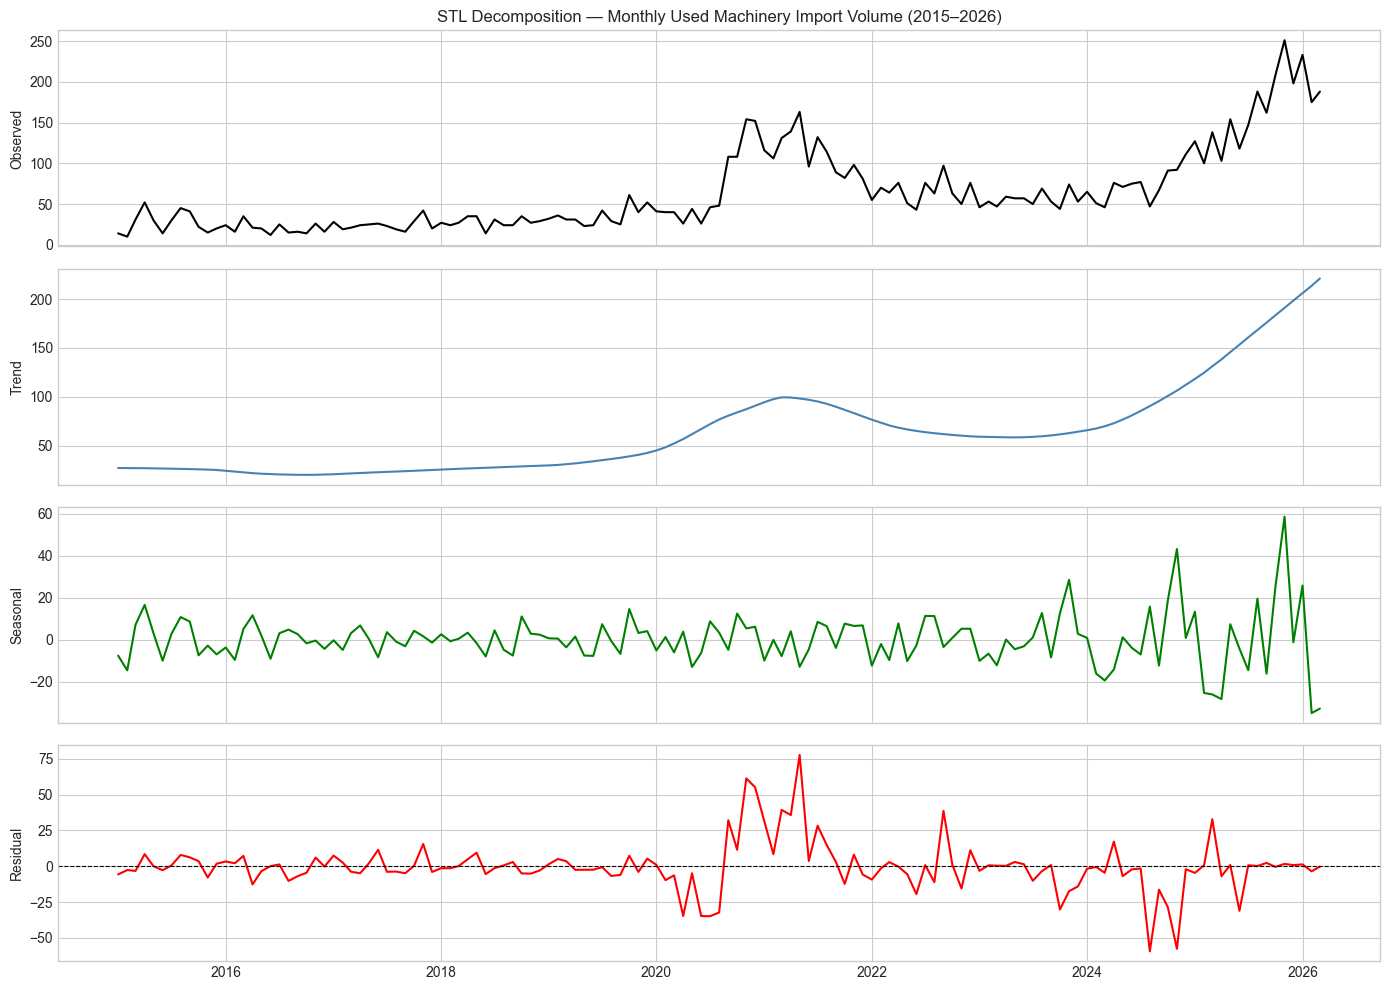

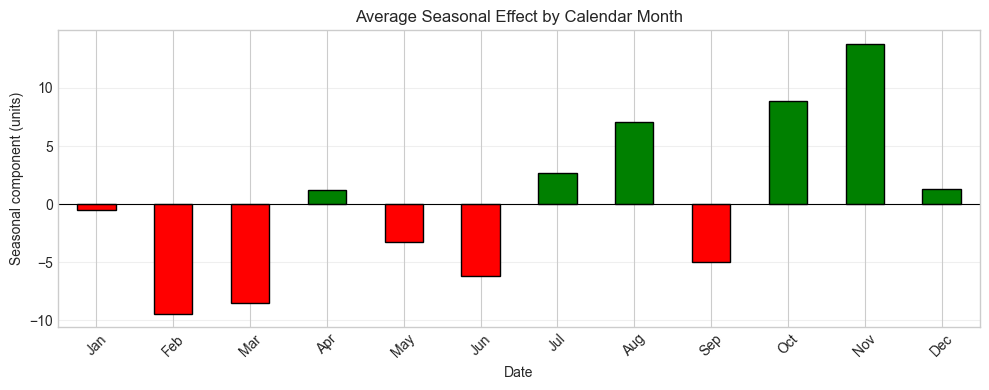


Peak import months (positive seasonal effect):
Date
11    13.788117
10     8.890099
8      7.102348
7      2.666656
12     1.302235
4      1.185526
dtype: float64


In [69]:
from statsmodels.tsa.seasonal import STL

# Build a clean monthly time series from the used machinery dataset
_df_stl = df_units.copy() # Corrected: Use the pre-loaded df_units DataFrame
_df_stl['Date'] = pd.to_datetime(
    _df_stl['ANO'].astype(str) + '-' + _df_stl['MES'].astype(str) + '-01'
)
ts_volume = _df_stl.groupby('Date').size().asfreq('MS').fillna(0)

# STL decomposition (robust=True reduces influence of outliers)
stl = STL(ts_volume, period=12, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, label, color in zip(
        axes,
        [stl_result.observed, stl_result.trend, stl_result.seasonal, stl_result.resid],
        ['Observed', 'Trend', 'Seasonal', 'Residual'],
        ['black', 'steelblue', 'green', 'red']):
    ax.plot(data, color=color, lw=1.5)
    ax.set_ylabel(label)
    if label == 'Residual':
        ax.axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('STL Decomposition — Monthly Used Machinery Import Volume (2015–2026)')
plt.tight_layout()
plt.show()

# Average seasonal pattern by calendar month
_monthly_seasonal = (
    pd.Series(stl_result.seasonal.values, index=stl_result.seasonal.index)
    .groupby(lambda d: d.month).mean()
)

plt.figure(figsize=(10, 4))
_monthly_seasonal.plot(kind='bar', color=['green' if v > 0 else 'red' for v in _monthly_seasonal], edgecolor='black')
plt.xticks(range(12),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
           rotation=45)
plt.title('Average Seasonal Effect by Calendar Month')
plt.ylabel('Seasonal component (units)')
plt.axhline(0, color='black', lw=0.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPeak import months (positive seasonal effect):")
print(_monthly_seasonal[_monthly_seasonal > 0].sort_values(ascending=False))


In [70]:
# ── Build Monthly Panel: Import_Volume + PBI_Construccion ─────────────────
df_gdp = pd.read_csv('cleaned_gdp_peru.csv')
df_gdp['Date'] = pd.to_datetime(df_gdp['Date'])

_ts = df_units.copy()
_ts['Date'] = pd.to_datetime(_ts['ANO'].astype(str) + '-' + _ts['MES'].astype(str) + '-01')
_ts = _ts[_ts['Date'] <= pd.to_datetime('2025-12-31')]

monthly_vol = _ts.groupby('Date').size().rename('Import_Volume')
monthly_vol.index = pd.to_datetime(monthly_vol.index)

df_gdp_monthly = df_gdp[['Date', 'PBI_Construccion']].set_index('Date').sort_index()
ts_data = monthly_vol.to_frame().join(df_gdp_monthly, how='inner').asfreq('MS').dropna()
ts_data = ts_data[ts_data.index <= pd.to_datetime('2025-12-31')]

print(f'ts_data: {ts_data.shape}  ({ts_data.index[0].date()} → {ts_data.index[-1].date()})')
print(ts_data.tail())


ts_data: (132, 2)  (2015-01-01 → 2025-12-01)
            Import_Volume  PBI_Construccion
Date                                       
2025-08-01            188        233.360658
2025-09-01            162        251.295255
2025-10-01            208        268.988237
2025-11-01            251        247.335666
2025-12-01            198        353.050702


### Stationarity Tests — ADF & KPSS (prerequisite for Johansen)

In [89]:
# ── Stationarity Tests: ADF and KPSS ──────────────────────────────────────
# Required before running Johansen cointegration: both series must be I(1).
# ADF  → H₀: unit root (non-stationary).  p < 0.05 → reject → stationary.
# KPSS → H₀: stationary.                  p < 0.05 → reject → non-stationary.
# Consistent signal for I(1): level is non-stationary; first difference is stationary.

from statsmodels.tsa.stattools import adfuller, kpss

def _stationarity_report(series, name):
    print(f"\n{'='*56}")
    print(f"  Series: {name}")
    print(f"{'='*56}")

    # ── Level ────────────────────────────────────────────────
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit    = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"  Level")
    print(f"    ADF  stat={adf_stat:8.4f}  p={adf_p:.4f}  cv5%={adf_crit['5%']:.4f}"
          f"  → {'STATIONARY ✓' if adf_p < 0.05 else 'non-stationary ✗'}")
    print(f"    KPSS stat={kpss_stat:8.4f}  p={kpss_p:.4f}  cv5%={kpss_crit['5%']:.4f}"
          f"  → {'non-stationary ✗' if kpss_p < 0.05 else 'STATIONARY ✓'}")

    # ── First difference ────────────────────────────────────
    d = series.diff().dropna()
    adf_d, adf_pd, _, _, adf_crit_d, _ = adfuller(d, autolag='AIC')
    kpss_d, kpss_pd, _, kpss_crit_d    = kpss(d, regression='c', nlags='auto')
    print(f"  First difference")
    print(f"    ADF  stat={adf_d:8.4f}  p={adf_pd:.4f}  cv5%={adf_crit_d['5%']:.4f}"
          f"  → {'STATIONARY ✓' if adf_pd < 0.05 else 'non-stationary ✗'}")
    print(f"    KPSS stat={kpss_d:8.4f}  p={kpss_pd:.4f}  cv5%={kpss_crit_d['5%']:.4f}"
          f"  → {'non-stationary ✗' if kpss_pd < 0.05 else 'STATIONARY ✓'}")

    is_I1 = (adf_p >= 0.05) and (kpss_p < 0.05) and (adf_pd < 0.05) and (kpss_pd >= 0.05)
    print(f"  ⟹  Integration order: {'I(1) ✓  — eligible for Johansen test' if is_I1 else 'AMBIGUOUS — review carefully'}")

_stationarity_report(ts_data['Import_Volume'],    'Import_Volume')
_stationarity_report(ts_data['PBI_Construccion'], 'PBI_Construccion')



  Series: Import_Volume
  Level
    ADF  stat= -0.1509  p=0.9441  cv5%=-2.8840  → non-stationary ✗
    KPSS stat=  1.1729  p=0.0100  cv5%=0.4630  → non-stationary ✗
  First difference
    ADF  stat=-17.1062  p=0.0000  cv5%=-2.8840  → STATIONARY ✓
    KPSS stat=  0.1551  p=0.1000  cv5%=0.4630  → STATIONARY ✓
  ⟹  Integration order: I(1) ✓  — eligible for Johansen test

  Series: PBI_Construccion
  Level
    ADF  stat= -1.1256  p=0.7048  cv5%=-2.8864  → non-stationary ✗
    KPSS stat=  1.0487  p=0.0100  cv5%=0.4630  → non-stationary ✗
  First difference
    ADF  stat= -4.2719  p=0.0005  cv5%=-2.8864  → STATIONARY ✓
    KPSS stat=  0.0716  p=0.1000  cv5%=0.4630  → STATIONARY ✓
  ⟹  Integration order: I(1) ✓  — eligible for Johansen test


### SARIMAX — Order Selection (AIC/BIC Grid Search) & Model Fit

In [72]:
# ── SARIMAX Order Selection: AIC/BIC Grid Search ──────────────────────────
# Grid: p,q ∈ {0,1,2}  d ∈ {0,1}  seasonal (P,D,Q,12) with P,D,Q ∈ {0,1}
# Training window: 2015–2024. Final model fitted on full ts_data (2015–2025).

from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

_train_cut  = pd.to_datetime('2024-12-01')
_ts_train   = ts_data[ts_data.index <= _train_cut]
_endog_tr   = _ts_train['Import_Volume']
_exog_tr    = _ts_train[['PBI_Construccion']]

_grid = list(itertools.product(range(3), range(2), range(3)))            # (p,d,q)
_seas = [(P, D, Q, 12) for P, D, Q in itertools.product(range(2), range(2), range(2))]

_best_aic, _best_order, _best_seas = np.inf, None, None
_table = []

for (p, d, q), s in itertools.product(_grid, _seas):
    try:
        _m = SARIMAX(_endog_tr, exog=_exog_tr,
                     order=(p, d, q), seasonal_order=s,
                     enforce_stationarity=False, enforce_invertibility=False)
        _r = _m.fit(disp=False)
        _table.append({'ARIMA': f'({p},{d},{q})', 'Seasonal': str(s),
                       'AIC': round(_r.aic, 2), 'BIC': round(_r.bic, 2)})
        if _r.aic < _best_aic:
            _best_aic, _best_order, _best_seas = _r.aic, (p, d, q), s
    except Exception:
        continue

_df_sel = pd.DataFrame(_table).sort_values('AIC').head(10)
print("Top 10 SARIMAX specifications by AIC (training sample 2015–2024):")
print(_df_sel.to_string(index=False))
print(f"\n✅  Selected: ARIMA{_best_order} × Seasonal{_best_seas}  AIC={_best_aic:.2f}")

# ── Fit on full ts_data (2015–2025) ───────────────────────────────────────
sarimax_model = SARIMAX(ts_data['Import_Volume'],
                        exog=ts_data[['PBI_Construccion']],
                        order=_best_order,
                        seasonal_order=_best_seas,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
results = sarimax_model.fit(disp=False)
print("\n--- SARIMAX Model Summary ---")
print(results.summary())

# ── Forecast setup ────────────────────────────────────────────────────────
last_pbi       = ts_data['PBI_Construccion'].iloc[-1]
future_periods = 12
forecast_index = pd.date_range(ts_data.index[-1] + pd.offsets.MonthBegin(1),
                               periods=future_periods, freq='MS')
growth_rates   = {
    'Optimistic (+5% GDP Growth)':       0.05,
    'Base Case (+3% GDP Growth)':        0.03,
    'Pessimistic (-2% GDP Contraction)': -0.02,
}
print(f"\nForecast window: {forecast_index[0].date()} → {forecast_index[-1].date()}")


Top 10 SARIMAX specifications by AIC (training sample 2015–2024):
  ARIMA      Seasonal    AIC    BIC
(0,1,2) (0, 1, 1, 12) 801.56 814.17
(0,1,2) (1, 1, 1, 12) 802.81 817.95
(1,1,2) (0, 1, 1, 12) 803.46 818.59
(1,1,2) (1, 1, 1, 12) 804.02 821.67
(2,1,2) (0, 1, 1, 12) 805.46 823.11
(2,1,2) (1, 1, 1, 12) 807.36 827.53
(0,1,1) (0, 1, 1, 12) 807.57 817.70
(0,1,1) (1, 1, 1, 12) 809.51 822.17
(1,1,1) (0, 1, 1, 12) 809.57 822.23
(1,0,2) (0, 1, 1, 12) 809.94 825.14

✅  Selected: ARIMA(0, 1, 2) × Seasonal(0, 1, 1, 12)  AIC=801.56

--- SARIMAX Model Summary ---
                                      SARIMAX Results                                       
Dep. Variable:                        Import_Volume   No. Observations:                  132
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -460.810
Date:                              Fri, 08 May 2026   AIC                            931.619
Time:                                      11:54:24   BIC             

### Structural Break Test — Chancay Megaport (Nov 2024)

In [73]:
# ── Structural Break Test: Chancay Megaport (Nov 2024) ───────────────────
# Known break date → dummy variable approach, equivalent to Chow (1960) for
# a single known breakpoint in a regression context.
#
# H₀: the Chancay opening had no significant level effect on monthly import
#     volume after conditioning on PBI_Construccion (the SARIMAX exog).
#
# Method: re-fit the same SARIMAX order with D_Chancay (=1 from Nov-2024)
# added as an exogenous dummy.  Two evidence pieces:
#   (a) t-test on the dummy coefficient  → direct significance
#   (b) ΔAIC (model with vs. without)   → whether break improves overall fit
# Limitation: only ~14 months of post-break data exist at time of writing;
# low post-break sample reduces power (Type-II error risk if β is small).

chancay_date   = pd.to_datetime('2024-11-01')
_D             = (ts_data.index >= chancay_date).astype(int)

exog_with_dummy              = ts_data[['PBI_Construccion']].copy()
exog_with_dummy['D_Chancay'] = _D
sarimax_chow = SARIMAX(ts_data['Import_Volume'],
                       exog=exog_with_dummy,
                       order=_best_order,
                       seasonal_order=_best_seas,
                       enforce_stationarity=False,
                       enforce_invertibility=False)
results_chow = sarimax_chow.fit(disp=False)

# ── Results table ─────────────────────────────────────────────────────────
_coef  = results_chow.params['D_Chancay']
_se    = results_chow.bse['D_Chancay']
_tstat = results_chow.tvalues['D_Chancay']
_pval  = results_chow.pvalues['D_Chancay']
_daic  = results.aic - results_chow.aic   # positive = dummy improves fit

print("=" * 60)
print("  Structural Break Test — Chancay Megaport (Nov 2024)")
print("=" * 60)
print(f"  SARIMAX order used : ARIMA{_best_order} × Seasonal{_best_seas}")
print()
print(f"  AIC without dummy  : {results.aic:.2f}")
print(f"  AIC with dummy     : {results_chow.aic:.2f}")
print(f"  ΔAIC               : {_daic:+.2f}  "
      f"({'dummy improves fit ✓' if _daic > 2 else 'negligible / no improvement'})")
print()
print(f"  D_Chancay  coef = {_coef:+.4f}")
print(f"             s.e. = {_se:.4f}")
print(f"             t    = {_tstat:.4f}")
print(f"             p    = {_pval:.4f}")
print()
if _pval < 0.05:
    print("  ⟹  SIGNIFICANT (p < 0.05) — reject H₀.")
    print(f"     The Chancay opening is associated with a level shift of "
          f"{_coef:+.1f} units/month in import volume, after controlling for GDP.")
else:
    print("  ⟹  NOT significant (p ≥ 0.05) — fail to reject H₀.")
    print("     No statistically detectable level break at α = 0.05.")
    print("     Note: power is limited with only ~14 post-break observations.")
    print("     The break may materialise as more data accumulate post-2025.")
print()
print("  Full model summary (with dummy):")
print(results_chow.summary())


  Structural Break Test — Chancay Megaport (Nov 2024)
  SARIMAX order used : ARIMA(0, 1, 2) × Seasonal(0, 1, 1, 12)

  AIC without dummy  : 931.62
  AIC with dummy     : 932.50
  ΔAIC               : -0.88  (negligible / no improvement)

  D_Chancay  coef = +19.0039
             s.e. = 33.0284
             t    = 0.5754
             p    = 0.5650

  ⟹  NOT significant (p ≥ 0.05) — fail to reject H₀.
     No statistically detectable level break at α = 0.05.
     Note: power is limited with only ~14 post-break observations.
     The break may materialise as more data accumulate post-2025.

  Full model summary (with dummy):
                                      SARIMAX Results                                       
Dep. Variable:                        Import_Volume   No. Observations:                  132
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -460.251
Date:                              Fri, 08 May 2026   AIC                            932.50


Forecast Interval for Optimistic (+5% GDP Growth):
  Final Month (2026-12):
  - Expected: 234.62
  - 95% CI: [146.40 to 322.84]

Forecast Interval for Base Case (+3% GDP Growth):
  Final Month (2026-12):
  - Expected: 233.20
  - 95% CI: [144.98 to 321.42]

Forecast Interval for Pessimistic (-2% GDP Contraction):
  Final Month (2026-12):
  - Expected: 229.64
  - 95% CI: [141.42 to 317.86]


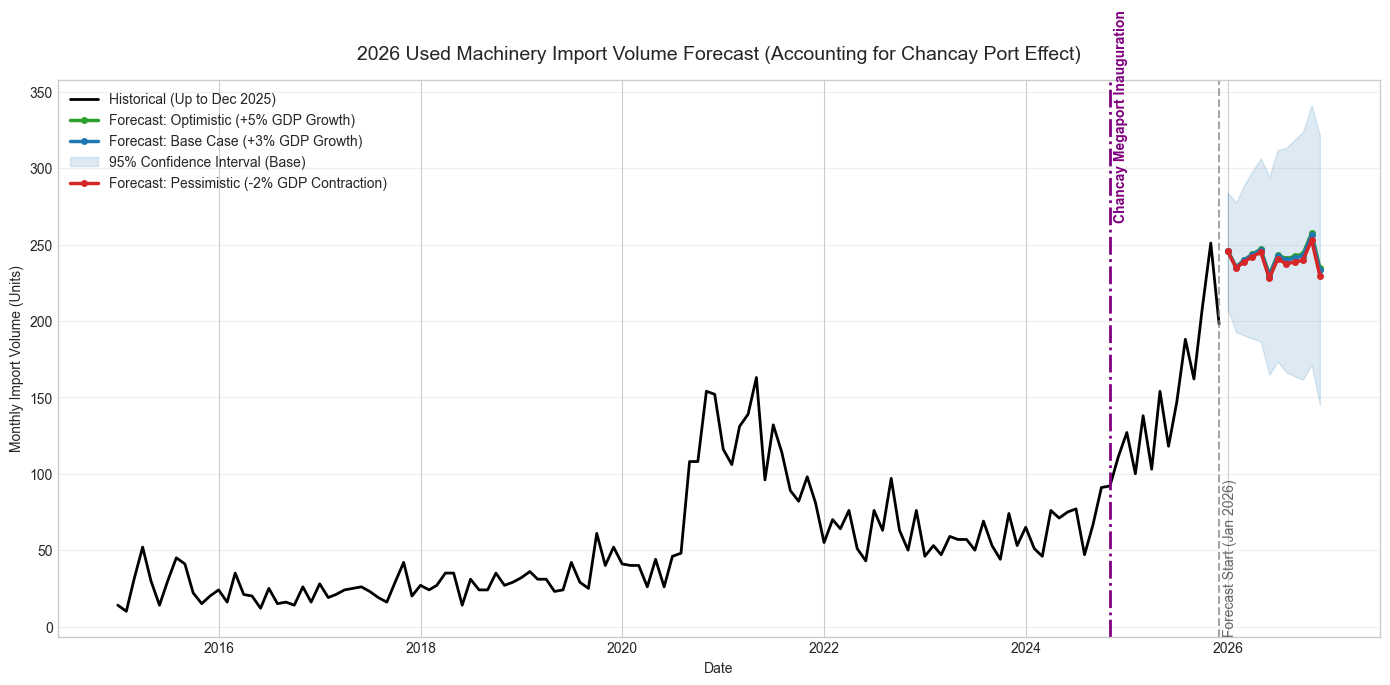

In [90]:
# 5. PLOTTING THE FAN CHART WITH CHANCAY EVENT
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(ts_data.index, ts_data['Import_Volume'], label='Historical (Up to Dec 2025)', color='black', linewidth=2)

colors = {'Optimistic (+5% GDP Growth)': '#2ca02c', 'Base Case (+3% GDP Growth)': '#1f77b4', 'Pessimistic (-2% GDP Contraction)': '#d62728'}
forecast_data = {}

for scenario_name, rate in growth_rates.items():
    monthly_rate = (1 + rate)**(1/12) - 1
    future_exo_values = [last_pbi * (1 + monthly_rate)**i for i in range(1, future_periods + 1)]
    future_exo = pd.DataFrame(future_exo_values, index=forecast_index, columns=['PBI_Construccion'])

    forecast = results.get_forecast(steps=future_periods, exog=future_exo)
    mean_forecast = forecast.predicted_mean
    forecast_data[scenario_name] = mean_forecast

    plt.plot(forecast_index, mean_forecast, label=f'Forecast: {scenario_name}', color=colors[scenario_name], linewidth=2.5, marker='o', markersize=4)
    
    # --- New: Print Interval Summary ---
    ci = forecast.conf_int()
    print(f"\nForecast Interval for {scenario_name}:")
    print(f"  Final Month ({forecast_index[-1].strftime('%Y-%m')}):")
    print(f"  - Expected: {mean_forecast.iloc[-1]:,.2f}")
    print(f"  - 95% CI: [{ci.iloc[-1, 0]:,.2f} to {ci.iloc[-1, 1]:,.2f}]")
    if scenario_name == 'Base Case (+3% GDP Growth)':
        ci = forecast.conf_int()
        plt.fill_between(forecast_index, ci.iloc[:, 0], ci.iloc[:, 1], color=colors[scenario_name], alpha=0.15, label='95% Confidence Interval (Base)')

# --- NEW: ADDING THE CHANCAY PORT MARKER ---
chancay_date = pd.to_datetime('2024-11-01')
plt.axvline(x=chancay_date, color='purple', linestyle='-.', linewidth=2)
# We calculate a good Y-position so the text stays near the top of the chart dynamically
y_pos = plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.75
plt.text(chancay_date + pd.DateOffset(days=15), y_pos, 'Chancay Megaport Inauguration',
         rotation=90, color='purple', fontweight='bold', fontsize=10)
# -------------------------------------------

# Chart Formatting
plt.title('2026 Used Machinery Import Volume Forecast (Accounting for Chancay Port Effect)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Monthly Import Volume (Units)')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)

# Forecast Start Line
plt.axvline(x=ts_data.index[-1], color='gray', linestyle='--', alpha=0.7)
plt.text(ts_data.index[-1] + pd.DateOffset(days=15), plt.ylim()[0], 'Forecast Start (Jan 2026)',
         rotation=90, verticalalignment='bottom', alpha=0.7)

plt.tight_layout()
plt.show()

In [75]:
# ── Johansen Cointegration Test ──────────────────────────────────────────
# Prerequisite: both series are I(1) (confirmed above).
# det_order=0 (restricted constant), k_ar_diff=1 (one lag in differences).

from statsmodels.tsa.vector_ar.vecm import coint_johansen

jres = coint_johansen(ts_data[['Import_Volume', 'PBI_Construccion']], det_order=0, k_ar_diff=1)

print("--- Johansen Cointegration Test ---")
print(f"{'Hypothesis':<18} {'Trace stat':>12} {'cv 90%':>10} {'cv 95%':>10} {'cv 99%':>10}  Decision")
print("-" * 72)
_rank = 0
for _r in range(len(jres.lr1)):
    _trace = jres.lr1[_r]
    _cv90, _cv95, _cv99 = jres.cvt[_r]
    _hyp   = f"H₀: rank ≤ {_r}"
    _dec   = "REJECT ✓" if _trace > _cv95 else "fail to reject"
    print(f"{_hyp:<18} {_trace:>12.4f} {_cv90:>10.4f} {_cv95:>10.4f} {_cv99:>10.4f}  {_dec}")
    if _trace > _cv95:
        _rank += 1

coint_rank_determined = max(_rank, 1)   # floor at 1 if borderline
print(f"\n⟹  Cointegration rank = {coint_rank_determined}  "
      f"({'used directly in VECM below' if _rank >= 1 else 'borderline — floored to 1'})")


--- Johansen Cointegration Test ---
Hypothesis           Trace stat     cv 90%     cv 95%     cv 99%  Decision
------------------------------------------------------------------------
H₀: rank ≤ 0            27.4281    13.4294    15.4943    19.9349  REJECT ✓
H₀: rank ≤ 1             0.0319     2.7055     3.8415     6.6349  fail to reject

⟹  Cointegration rank = 1  (used directly in VECM below)


Det. terms outside the coint. relation & lagged endog. parameters for equation Import_Volume
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.5102      8.200      0.916      0.360      -8.561      23.582
L1.Import_Volume       -0.4410      0.084     -5.262      0.000      -0.605      -0.277
L1.PBI_Construccion     0.0615      0.042      1.475      0.140      -0.020       0.143
Det. terms outside the coint. relation & lagged endog. parameters for equation PBI_Construccion
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  95.1213     17.342      5.485      0.000      61.132     129.111
L1.Import_Volume        0.1003      0.177      0.566      0.572      -0.247       0.448
L1.PBI_Construccion

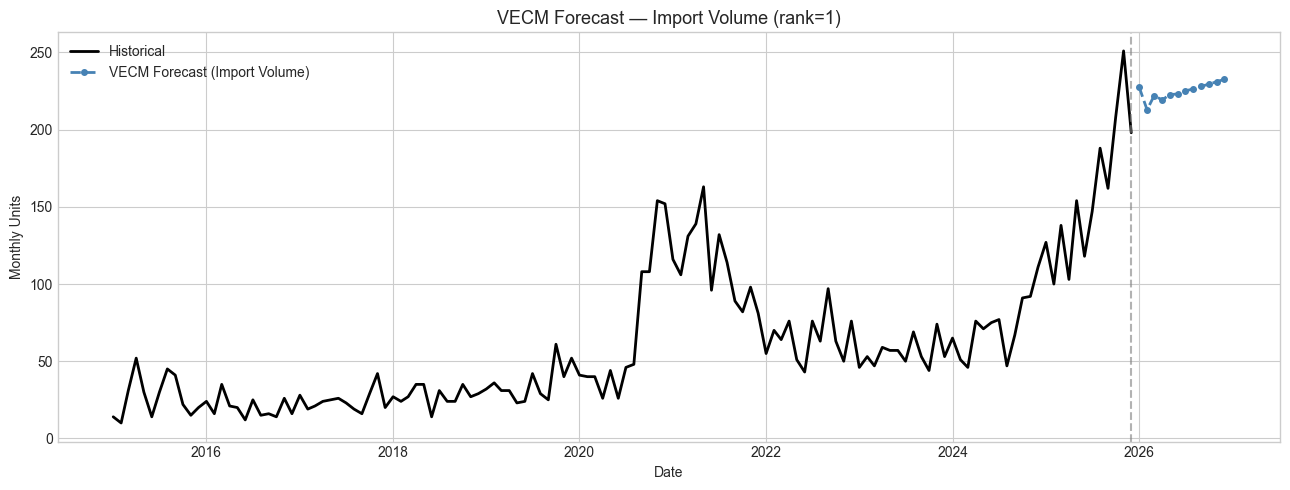

In [78]:
# ── VECM: Error-Correction Model ──────────────────────────────────────────
# coint_rank comes from the Johansen trace test above (not hard-coded).

from statsmodels.tsa.vector_ar.vecm import VECM

vecm_model = VECM(ts_data[['Import_Volume', 'PBI_Construccion']],
                  k_ar_diff=1,
                  coint_rank=coint_rank_determined,
                  deterministic='co')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

# ── 12-month forecast ─────────────────────────────────────────────────────
forecast_vecm  = vecm_res.predict(steps=12)
forecast_dates = pd.date_range(ts_data.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts_data.index, ts_data['Import_Volume'], label='Historical', color='black', lw=2)
ax.plot(forecast_dates, forecast_vecm[:, 0], label='VECM Forecast (Import Volume)', color='steelblue',
        lw=2, marker='o', markersize=4, linestyle='--')
ax.axvline(ts_data.index[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title(f'VECM Forecast — Import Volume (rank={coint_rank_determined})', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Monthly Units')
ax.legend(); plt.tight_layout(); plt.show()


In [36]:
#!pip install arch


### ARCH-LM Test — Validating Volatility Clustering Before GARCH

--- ARCH-LM Test on SARIMAX Residuals ---
LM Statistic : 18.4160
LM p-value   : 0.0010  → ARCH effects PRESENT — GARCH is justified


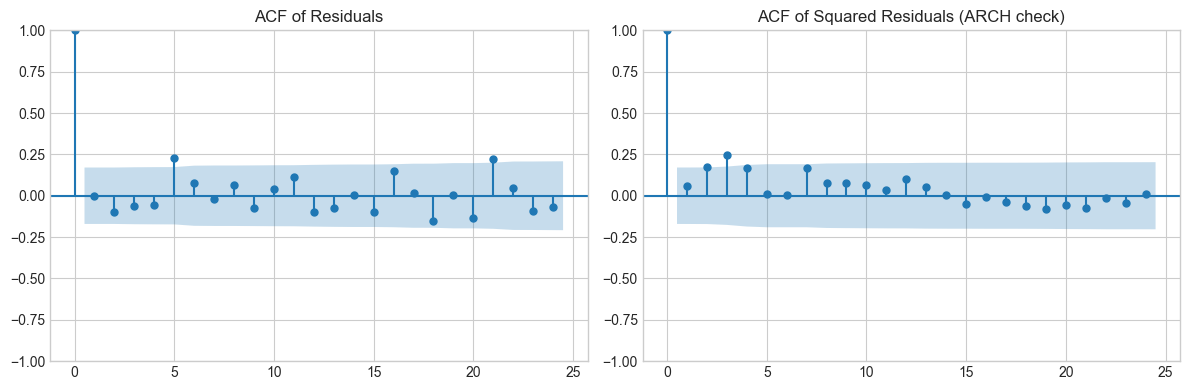

In [77]:
from statsmodels.stats.diagnostic import het_arch

# ARCH-LM test: does the variance cluster over time in the SARIMAX residuals?
# If p-value < 0.05 → ARCH effects exist → GARCH is justified
lm_stat, lm_pval, f_stat, f_pval = het_arch(results.resid, nlags=4)

print("--- ARCH-LM Test on SARIMAX Residuals ---")
print(f"LM Statistic : {lm_stat:.4f}")
print(f"LM p-value   : {lm_pval:.4f}  {'→ ARCH effects PRESENT — GARCH is justified' if lm_pval < 0.05 else '→ No ARCH effects — GARCH may not add value'}")

# Visual check: squared residuals autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(results.resid, ax=axes[0], lags=24, title='ACF of Residuals')
plot_acf(results.resid**2, ax=axes[1], lags=24, title='ACF of Squared Residuals (ARCH check)')
plt.tight_layout()
plt.show()


In [76]:
#garch to get crazyyy with the volatilityy

from arch import arch_model

# We model the residuals (errors) of your SARIMAX model
residuals = results.resid
garch = arch_model(residuals, vol='Garch', p=1, q=1)
garch_fit = garch.fit(disp='off')

print("\n--- GARCH Volatility Summary ---")
print(garch_fit.summary())


--- GARCH Volatility Summary ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -573.026
Distribution:                  Normal   AIC:                           1154.05
Method:            Maximum Likelihood   BIC:                           1165.58
                                        No. Observations:                  132
Date:                Fri, May 08 2026   Df Residuals:                      131
Time:                        11:55:34   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1.6990      1.353    

### Lead Scoring & Conclusions

In [79]:
# 1. Create a Lead Score based on your findings
# Three components (max 100 pts):
#   - Market Presence  (30 pts): normalised total FOB spend
#   - Wallet Gap       (40 pts): share NOT yet sourced from CPtrucks / Europe
#   - Growth Signal    (30 pts): flagged as Rising Star in clustering analysis
prospect_list = sow_final.copy()

prospect_list['is_rising_star'] = prospect_list.index.isin(success_stories.index)

prospect_list['Lead_Score'] = (
    (prospect_list['Total_Imported_FOB'] / prospect_list['Total_Imported_FOB'].max() * 30) +
    ((100 - prospect_list['Share_of_Wallet']) / 100 * 40) +
    (prospect_list['is_rising_star'].astype(int) * 30)
)

# 2. Add the "MBA Hook" (Which product to offer them)
prospect_list['Suggested_Offer'] = prospect_list['Main_Origin'].apply(
    lambda x: "Caterpillar Excavator" if x == "SUECIA" else "Volvo Loader"
)

# 3. Final ranking
belgian_hit_list = prospect_list.sort_values('Lead_Score', ascending=False)
display(belgian_hit_list[[
    'CLIENT_NAME', 'Share_of_Wallet', 'Total_Imported_FOB',
    'is_rising_star', 'Suggested_Offer', 'Lead_Score'
]].head(15))


,CLIENT_NAME,Share_of_Wallet,Total_Imported_FOB,is_rising_star,Suggested_Offer,Lead_Score
RUC IMPORTADOR,,,,,,
20606365196,LARF BUSINESS E.I.R.L.,0.627332,3830031.78,True,Volvo Loader,80.853784
20603430167,JYC INTERNATIONAL BUSINESS S.A.C.,1.025657,2147210.02,True,Caterpillar Excavator,75.815315
20609926440,ANKARA PERU E.I.R.L,1.210379,974901.41,True,Volvo Loader,72.342458
20602250866,FC MACHINERY & CONSTRUCTION E.I.R.L.,33.097034,3472685.80,True,Volvo Loader,66.829821
20517931536,KARLA EQUIPMENT S.A.C.,15.814947,10347040.79,False,Volvo Loader,63.674021
20601770815,DAMICON BUSINESS S.A.C.,4.401883,7689277.56,False,Caterpillar Excavator,60.533382
20490425668,KALICANTO PERU EIRL.,20.238895,5719062.23,False,Caterpillar Excavator,48.486175
20519006422,TACKLLA PERU SAC,23.876518,2025270.16,False,Volvo Loader,36.321420
20456340785,INVERSIONES Y NEGOCIOS B & J CONTRATISTAS GENE...,27.714781,86600.00,False,Volvo Loader,29.165174


In [80]:
# ── Blue Ocean Prospects: European Share of Wallet ────────────────────────
# Logic:
#   1. For every importer in df_units, compute total FOB and the share
#      sourced from European countries (proxy for CPtrucks-style suppliers).
#   2. Exclude known CPtrucks clients (sow_final index).
#   3. Flag companies with high total spend but low European sourcing —
#      these are the real Blue Ocean: big buyers who haven't tapped Europe yet.

_EUROPE = {
    'ALEMANIA',
    'AUSTRIA', 'BELGICA', 'BULGARIA', 'ESLOVENIA', 'ESPANA',
    'FINLANDIA', 'FRANCIA', 'IRLANDA {EIRE}', 'ITALIA', 'LITUANIA',
    'PAISES BAJOS', 'POLONIA', 'PORTUGAL', 'REINO UNIDO',
    'REPUBLICA CHECA', 'SUECIA', 'SUIZA',
}

_known_rucs = set(sow_final.index.astype(str))

# ── Per-importer aggregation ──────────────────────────────────────────────
_df = df_units.copy()
_df['RUC IMPORTADOR'] = _df['RUC IMPORTADOR'].astype(str)
_df['is_european']    = _df['PAIS DE ORIGEN'].isin(_EUROPE)

_agg = _df.groupby('RUC IMPORTADOR').agg(
    CLIENT_NAME   = ('IMPORTADOR',      'first'),
    Total_FOB     = ('US$ FOB',         'sum'),
    European_FOB  = ('US$ FOB',         lambda x: x[_df.loc[x.index, 'is_european']].sum()),
    Num_Shipments = ('US$ FOB',         'count'),
    Main_Origin   = ('PAIS DE ORIGEN',  lambda x: x.value_counts().index[0]),
    Main_Product  = ('PRODUCTO',        lambda x: x.value_counts().index[0]
                                        if x.notna().any() else 'UNKNOWN'),
    Department    = ('DEPARTAMENTO DE IMPORTADOR', lambda x: x.value_counts().index[0]),
).reset_index()

_agg['European_SOW_pct'] = (_agg['European_FOB'] / _agg['Total_FOB'] * 100).round(2)

# ── Filter: exclude CPtrucks clients, keep meaningful spend ───────────────
_min_fob = 1_000_000   # USD — at least $1M total machinery spend

blue_ocean = (
    _agg[
        (_agg['Total_FOB'] >= _min_fob)
    ]
    .sort_values(['European_SOW_pct', 'Total_FOB'], ascending=[True, False])
    .reset_index(drop=True)
)

blue_ocean.index += 1   # 1-based rank

print(f"Universe : {len(_agg):,} importers in df_units")
print(f"Blue Ocean candidates (FOB >= ${_min_fob:,}) : {len(blue_ocean)}")
print()
print("-- TOP 20 BLUE OCEAN PROSPECTS --")
print("   Ranked by lowest European SoW first, then highest total spend")
print()

_display_cols = ['CLIENT_NAME', 'Total_FOB', 'European_FOB',
                 'European_SOW_pct', 'Num_Shipments', 'Main_Origin',
                 'Main_Product', 'Department']

display(
    blue_ocean[_display_cols]
    .head(20)
    .style
    .format({'Total_FOB': '${:,.0f}', 'European_FOB': '${:,.0f}',
             'European_SOW_pct': '{:.1f}%'})
    .background_gradient(subset=['European_SOW_pct'], cmap='RdYlGn')
    .background_gradient(subset=['Total_FOB'], cmap='Blues')
)

# ── Export ─────────────────────────────────────────────────────────────────
blue_ocean[_display_cols].to_csv('CPTRUCKS_PROSPECTS_1M.csv', index_label='Rank')
print("Exported: CPTRUCKS_PROSPECTS_1M.csv")


Universe : 1,586 importers in df_units
Blue Ocean candidates (FOB >= $1,000,000) : 80

-- TOP 20 BLUE OCEAN PROSPECTS --
   Ranked by lowest European SoW first, then highest total spend



,CLIENT_NAME,Total_FOB,European_FOB,European_SOW_pct,Num_Shipments,Main_Origin,Main_Product,Department
1,MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,"$9,789,632",$0,0.0%,103,CHINA,EXCAVADORA DE ORUGA,UNKNOWN
2,ORVISA SOCIEDAD ANONIMA,"$6,009,141",$0,0.0%,60,CHINA,EXCAVADORA,LORETO
3,STRACON GYM S.A.,"$3,615,694",$0,0.0%,8,ESTADOS UNIDOS,PERFORADORA HIDRAULICA,LIMA
4,UNIMAQ S.A.,"$3,420,497",$0,0.0%,37,CHINA,EXCAVADORA,LIMA
5,BANCO DE CREDITO DEL PERU,"$3,371,250",$0,0.0%,8,ESTADOS UNIDOS,MOTONIVELADORA,LIMA
6,MINERA BARRICK MISQUICHILCA SA,"$2,698,328",$0,0.0%,3,JAPON,MOTONIVELADORA,LIMA
7,BEIJING SHOUGANG MINE CONSTRUCTION ENGINEERING CO. LTD. SUCURSAL DEL PERU,"$2,634,750",$0,0.0%,5,CHINA,EXCAVADORA DE 10 M3No SERIE:TZ,UNKNOWN
8,MULTISERVICIOS MAQUIRENT S.R.L,"$2,034,236",$0,0.0%,7,CHINA,EXCAVADORA HIDR-ULICA,UNKNOWN
9,"BEDROCK TRADING CO., LIMITED - SUCURSAL DEL PERU","$1,855,145",$0,0.0%,18,CHINA,EXCAVADORA,UNKNOWN
10,A K DRILLING INTERNATIONAL S.A.,"$1,748,734",$0,0.0%,5,CANADA,MAQUINA PERFORADORA,LIMA


Exported: CPTRUCKS_PROSPECTS_1M.csv


### Per-Client & Prospect Forecast — Growth Trajectory & Model Profile

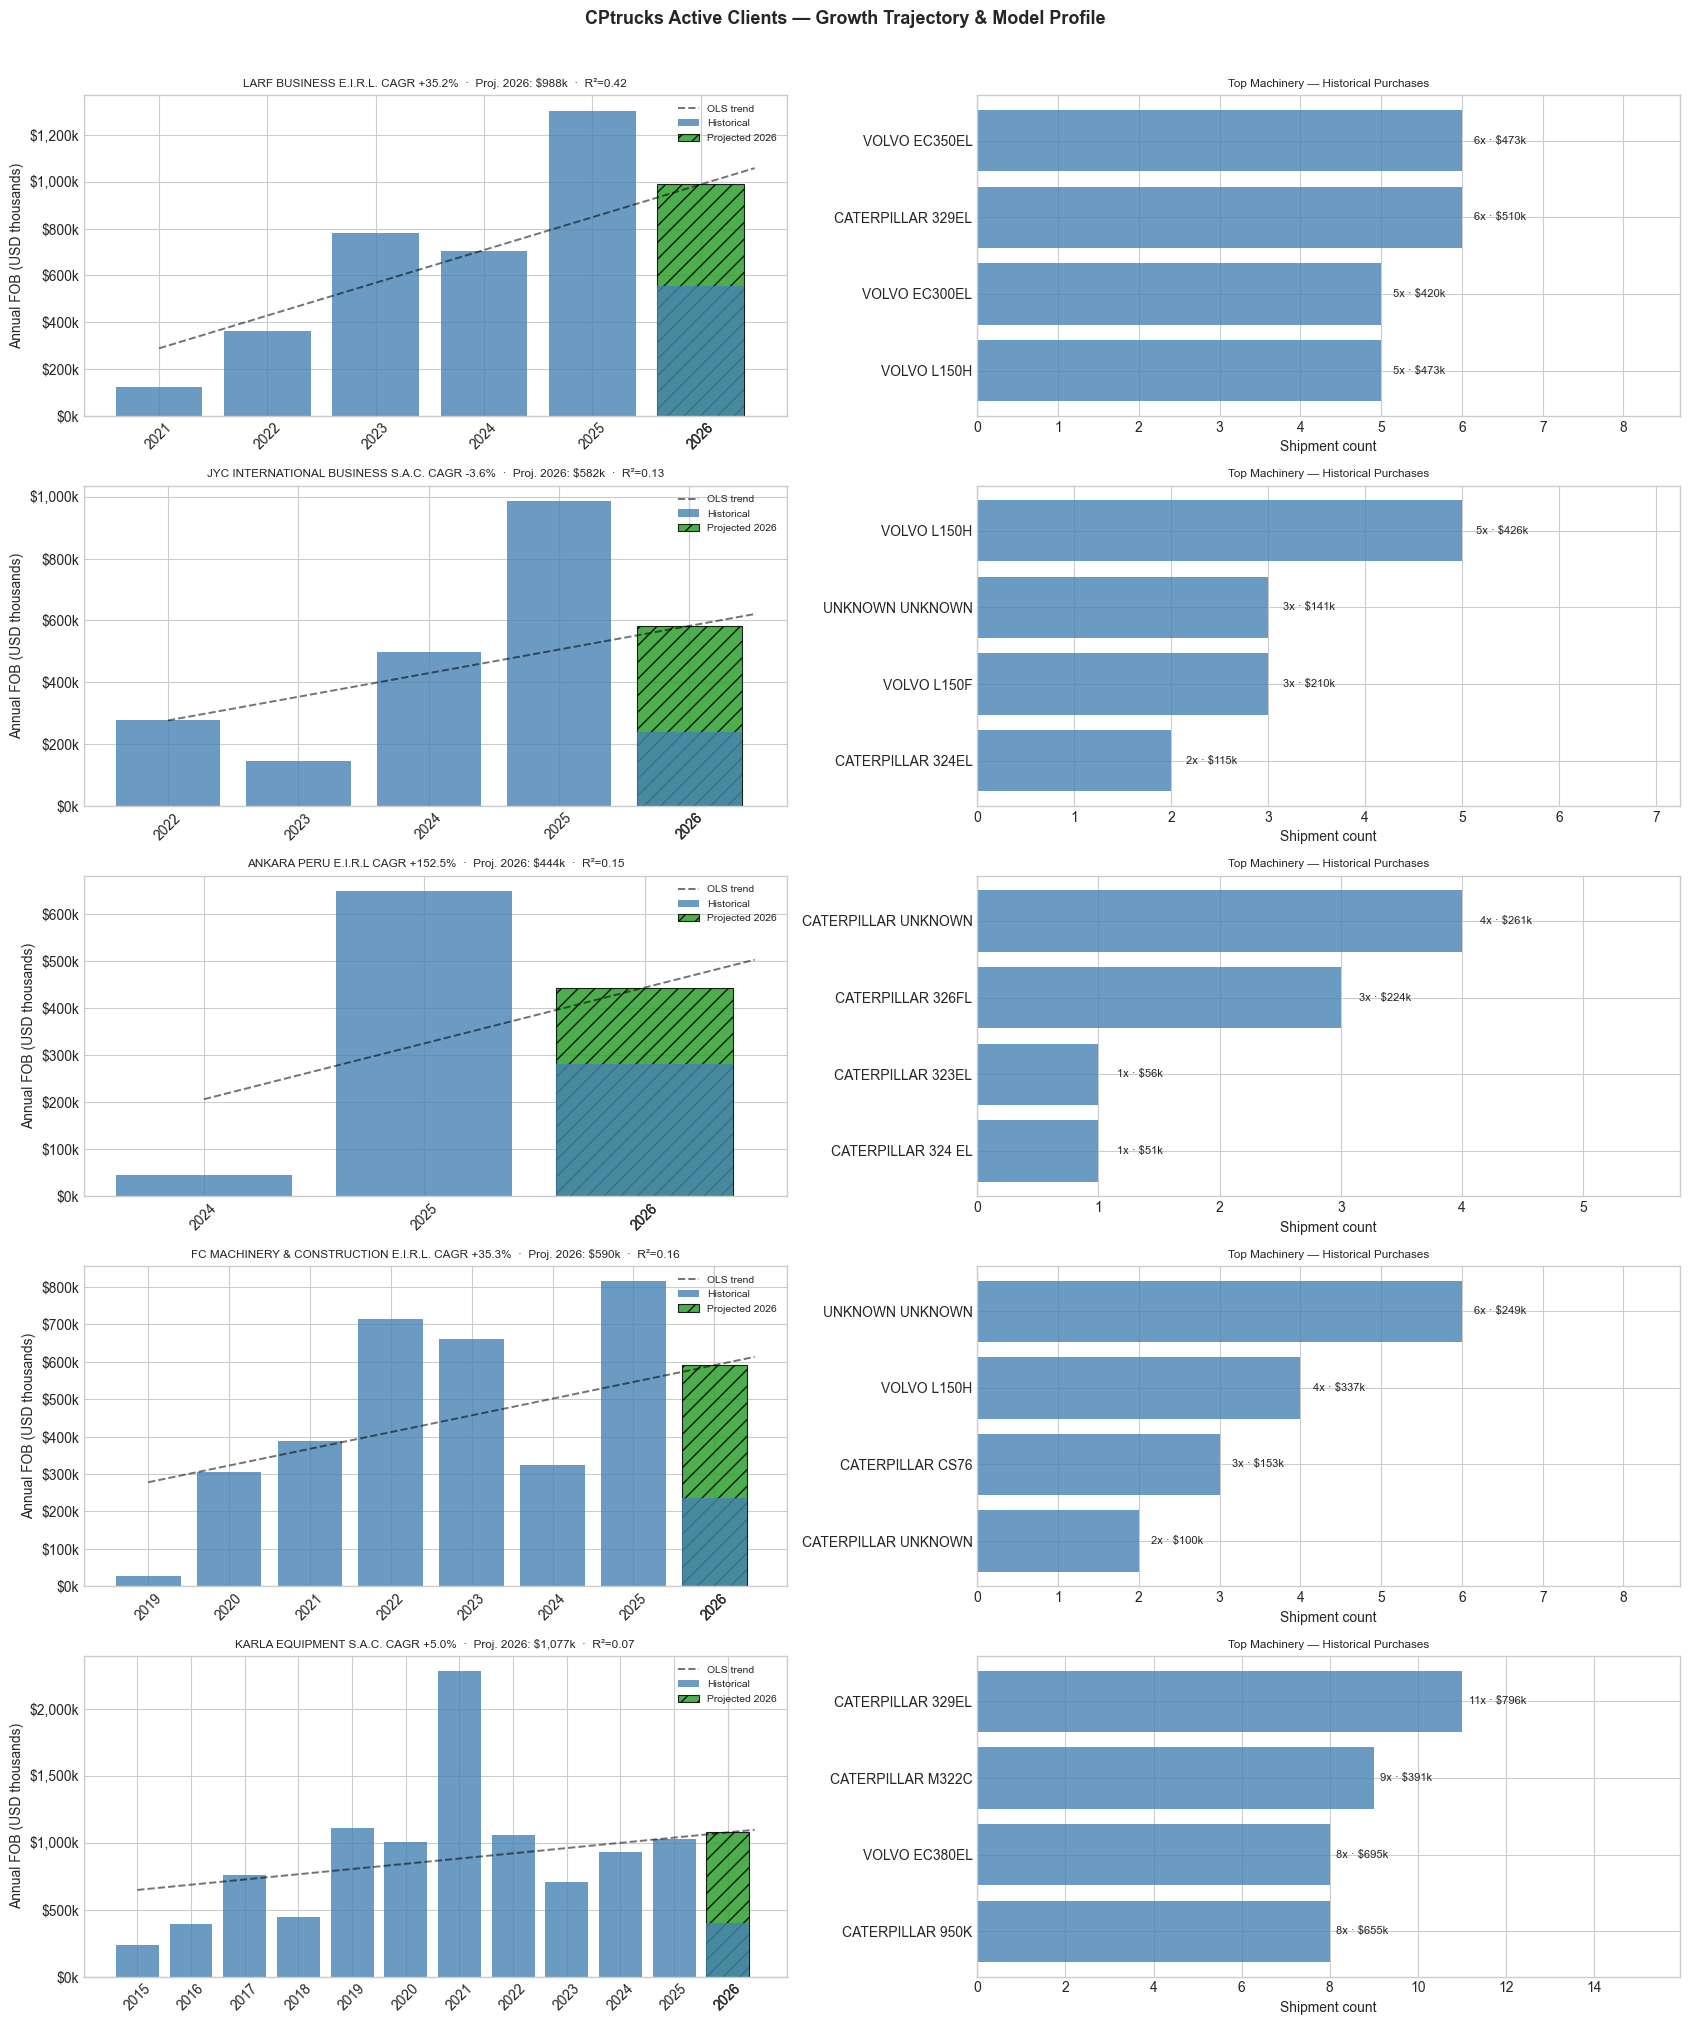

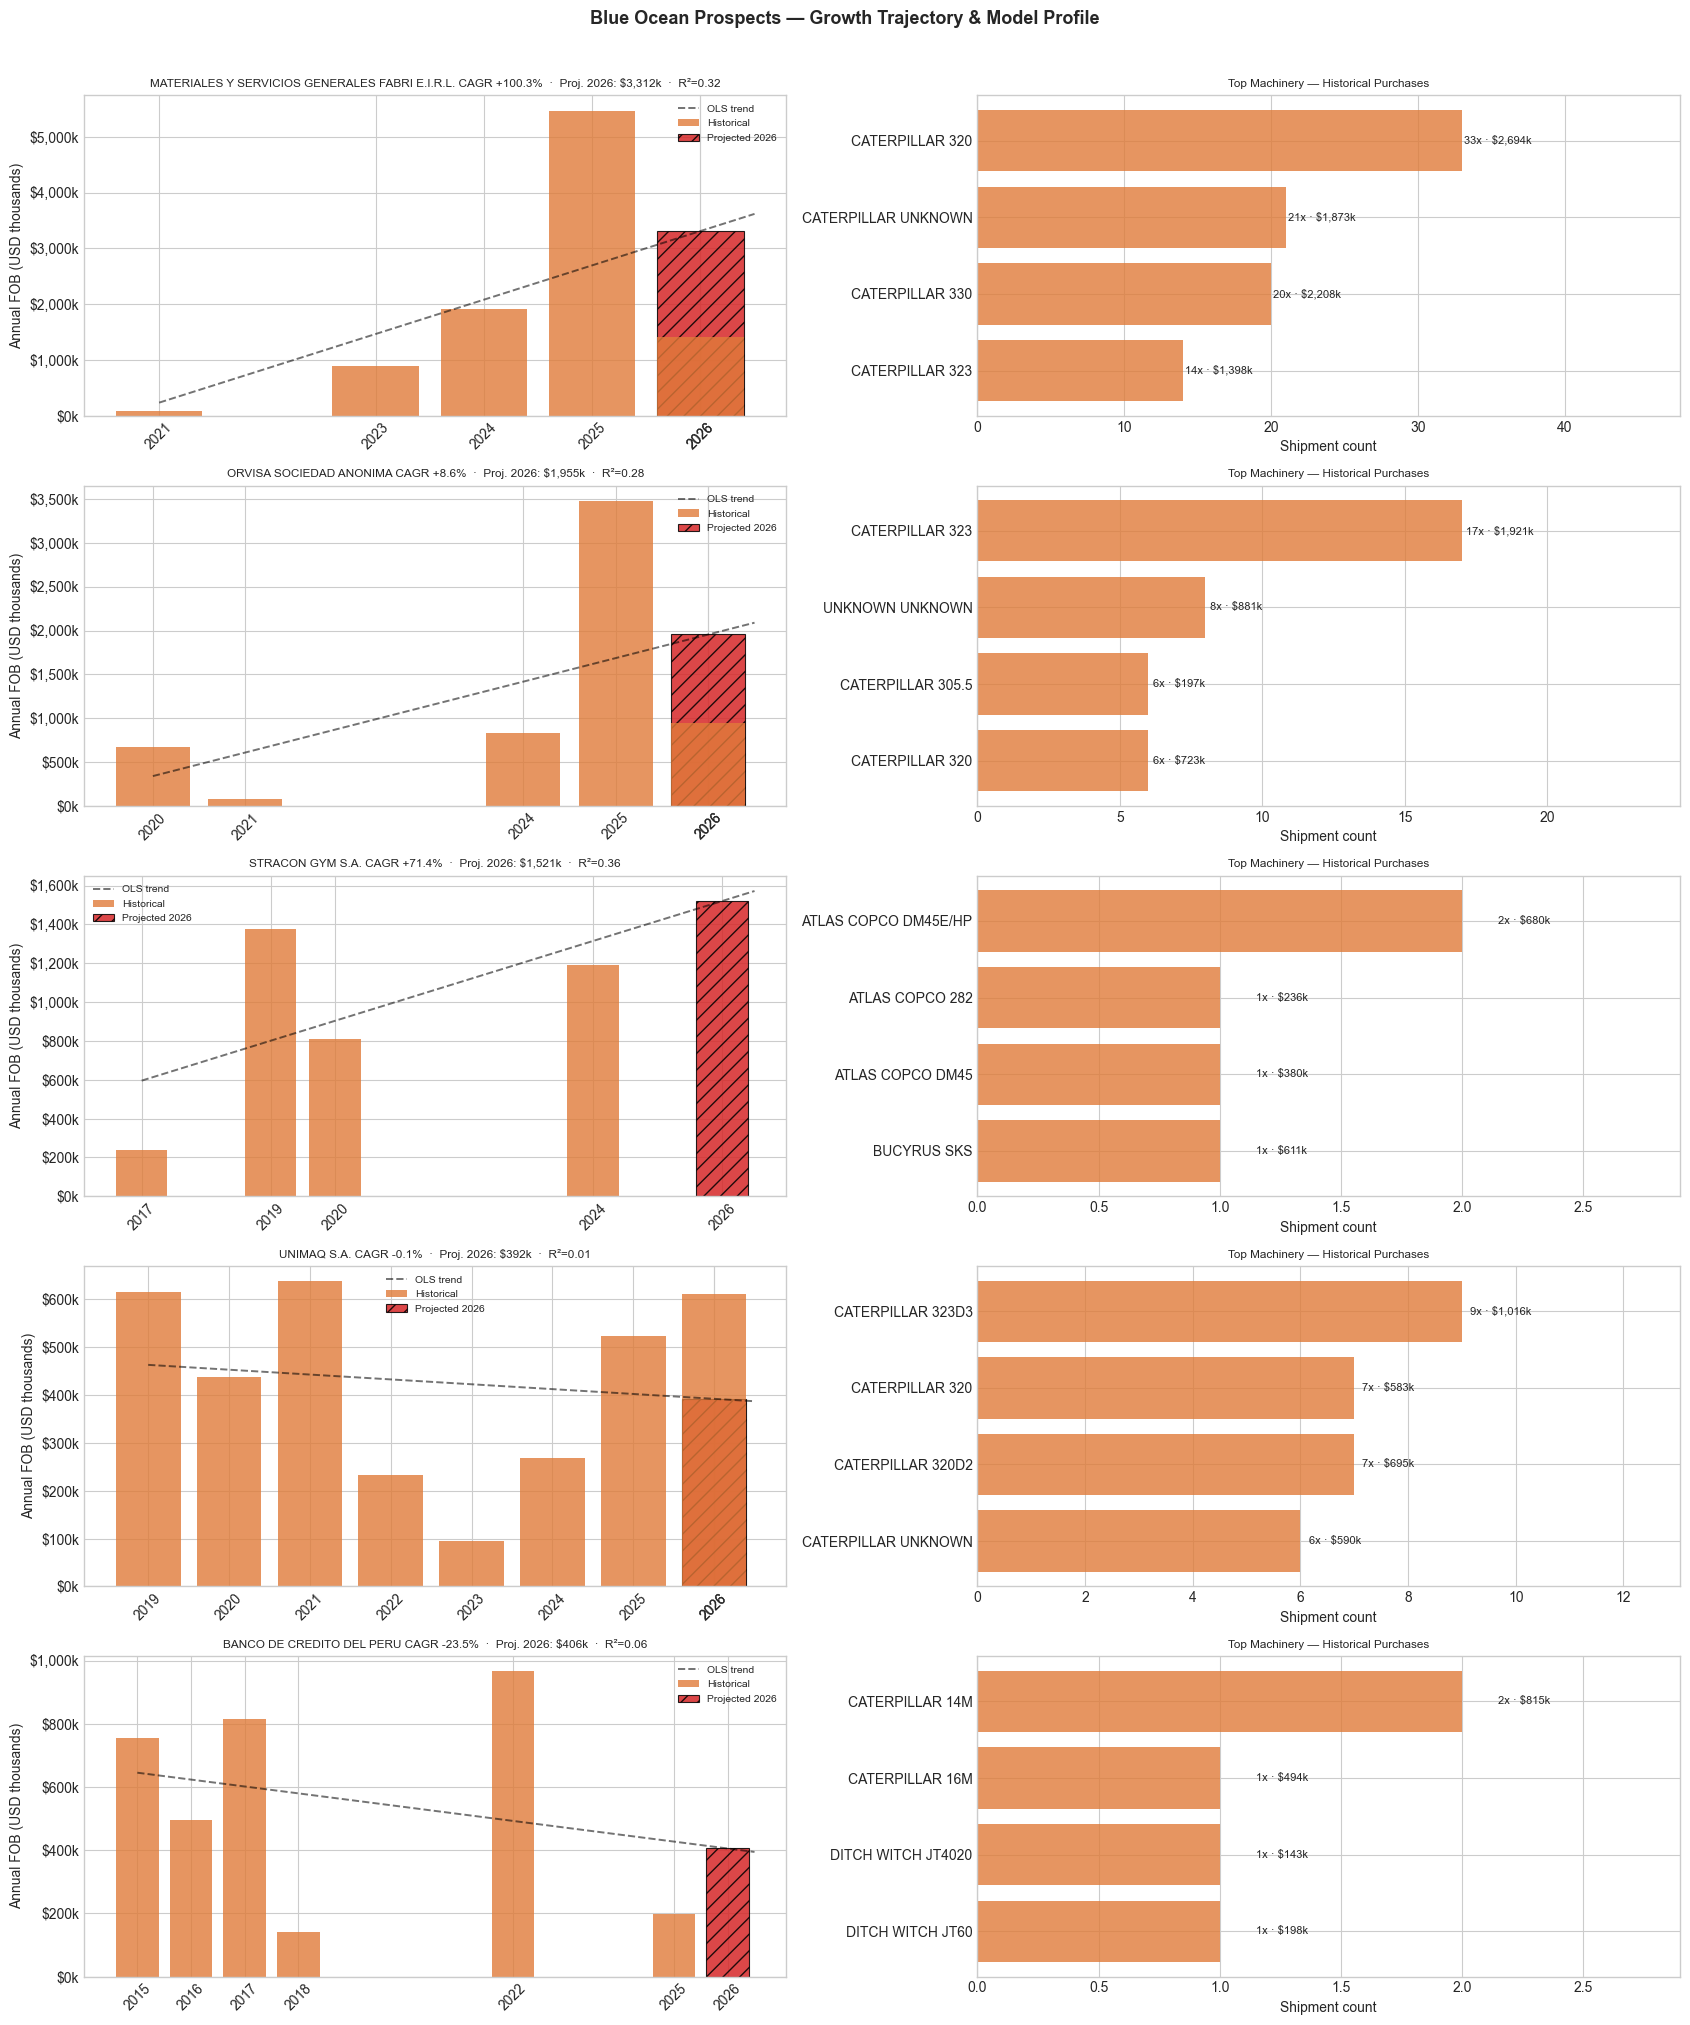


── QUICK-ACTION TABLE FOR CPTRUCKS ─────────────────────────────────


,Type,CAGR,Proj. 2026 FOB,R²,Top 3 Models
Company,,,,,
LARF BUSINESS E.I.R.L.,Client,+35.2%,$988k,0.42,VOLVO EC350EL | CATERPILLAR 329EL | VOLVO EC300EL
JYC INTERNATIONAL BUSINESS S.A.C.,Client,-3.6%,$582k,0.13,VOLVO L150H | UNKNOWN UNKNOWN | VOLVO L150F
ANKARA PERU E.I.R.L,Client,+152.5%,$444k,0.15,CATERPILLAR UNKNOWN | CATERPILLAR 326FL | CATERPILLAR 323EL
FC MACHINERY & CONSTRUCTION E.I.R.L.,Client,+35.3%,$590k,0.16,UNKNOWN UNKNOWN | VOLVO L150H | CATERPILLAR CS76
KARLA EQUIPMENT S.A.C.,Client,+5.0%,"$1,077k",0.07,CATERPILLAR 329EL | CATERPILLAR M322C | VOLVO EC380EL
MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,Prospect,+100.3%,"$3,312k",0.32,CATERPILLAR 320 | CATERPILLAR UNKNOWN | CATERPILLAR 330
ORVISA SOCIEDAD ANONIMA,Prospect,+8.6%,"$1,955k",0.28,CATERPILLAR 323 | UNKNOWN UNKNOWN | CATERPILLAR 305.5
STRACON GYM S.A.,Prospect,+71.4%,"$1,521k",0.36,ATLAS COPCO DM45E/HP | ATLAS COPCO 282 | ATLAS COPCO DM45
UNIMAQ S.A.,Prospect,-0.1%,$392k,0.01,CATERPILLAR 323D3 | CATERPILLAR 320 | CATERPILLAR 320D2


In [82]:
# ── Per-Client & Prospect Forecast: Growth Trajectory & Model Profile ─────
# For each top client (ranked by Lead Score) and top Blue Ocean prospect:
#   (a) Annual FOB history + linear trend + 2026 projection
#   (b) Top machinery models by shipment count
#   (c) Summary quick-action table for CPtrucks
#
# NOTE: Projections use OLS linear trend on annual FOB — a deliberate choice
# given sparse individual-client series (typically 3–8 annual obs). This is
# a trend extrapolation, not a structural forecast. Treat as directional.

from scipy.stats import linregress as _linreg

N_TOP = 5   # entities per group (clients / prospects)

# ── Identify top entities ─────────────────────────────────────────────────
_df_u = df_units.copy()
_df_u['RUC IMPORTADOR'] = _df_u['RUC IMPORTADOR'].astype(str)

_client_rucs  = belgian_hit_list.head(N_TOP).index.astype(str).tolist()
_client_names = belgian_hit_list.head(N_TOP)['CLIENT_NAME'].to_dict()
_client_names  = {str(k): v for k, v in _client_names.items()}

_prospect_rucs  = blue_ocean.head(N_TOP)['RUC IMPORTADOR'].astype(str).tolist()
_prospect_names = blue_ocean.head(N_TOP).set_index('RUC IMPORTADOR')['CLIENT_NAME'].to_dict()

# ── Annual FOB aggregation ────────────────────────────────────────────────
_ann = (
    _df_u.groupby(['RUC IMPORTADOR', 'ANO'])['US$ FOB']
    .sum().reset_index()
)

# ── Helper: linear trend + 2026 projection ───────────────────────────────
def _forecast(ruc):
    d = _ann[_ann['RUC IMPORTADOR'] == ruc].sort_values('ANO')
    if len(d) < 2:
        return None
    slope, intercept, r, _, _ = _linreg(d['ANO'], d['US$ FOB'])
    proj = max(intercept + slope * 2026, 0)
    fob0 = d['US$ FOB'].iloc[0]
    cagr = ((d['US$ FOB'].iloc[-1] / fob0) ** (1 / (len(d) - 1)) - 1) * 100 if fob0 > 0 else 0
    return dict(years=d['ANO'].values, fob=d['US$ FOB'].values,
                slope=slope, intercept=intercept,
                proj=proj, r2=r**2, cagr=cagr)

# ── Helper: top models ────────────────────────────────────────────────────
def _top_models(ruc, n=4):
    sub = _df_u[_df_u['RUC IMPORTADOR'] == ruc].copy()
    sub['Label'] = (sub['MARCA_CLEAN'].fillna('?') + ' ' +
                    sub['MODELO'].fillna('')).str.strip()
    return (sub.groupby('Label')
               .agg(Count=('US$ FOB', 'count'), FOB=('US$ FOB', 'sum'))
               .sort_values('Count', ascending=False)
               .head(n).reset_index())

# ── Plot function ─────────────────────────────────────────────────────────
def _plot_group(rucs, names, title, c_hist, c_proj):
    n = len(rucs)
    fig, axes = plt.subplots(n, 2, figsize=(17, 4 * n))
    if n == 1:
        axes = np.array([axes])
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for i, ruc in enumerate(rucs):
        ax_l, ax_r = axes[i]
        name = names.get(ruc, ruc)
        fc   = _forecast(ruc)

        # ── Left: FOB trend + projection ─────────────────────────────────
        if fc is None:
            ax_l.text(0.5, 0.5, 'Insufficient data (<2 years)',
                      ha='center', va='center', transform=ax_l.transAxes)
            ax_l.set_title(name, fontsize=9)
        else:
            # Historical bars
            ax_l.bar(fc['years'], fc['fob'] / 1e3,
                     color=c_hist, alpha=0.8, zorder=2, label='Historical')
            # 2026 projection bar
            ax_l.bar(2026, fc['proj'] / 1e3,
                     color=c_proj, alpha=0.85, hatch='//',
                     edgecolor='black', lw=0.8, label='Projected 2026')
            # Trend line through historical + 2026
            _x  = np.linspace(fc['years'].min(), 2026.5, 200)
            _y  = (fc['slope'] * _x + fc['intercept']) / 1e3
            ax_l.plot(_x, _y, color='black', lw=1.4,
                      ls='--', alpha=0.55, label='OLS trend')

            _sign = '+' if fc['cagr'] >= 0 else ''
            ax_l.set_title(
                f"{name} "
                f"CAGR {_sign}{fc['cagr']:.1f}%  ·  "
                f"Proj. 2026: ${fc['proj']/1e3:,.0f}k  ·  "
                f"R²={fc['r2']:.2f}",
                fontsize=8.5
            )
            ax_l.set_ylabel('Annual FOB (USD thousands)')
            ax_l.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
            ax_l.legend(fontsize=7.5)
            ax_l.set_xticks(list(fc['years']) + [2026])
            ax_l.tick_params(axis='x', rotation=45)

        # ── Right: Top models ─────────────────────────────────────────────
        mods = _top_models(ruc)
        if mods.empty:
            ax_r.text(0.5, 0.5, 'No model data',
                      ha='center', va='center', transform=ax_r.transAxes)
            ax_r.axis('off')
        else:
            _lbls = mods['Label'].values[::-1]
            _cnts = mods['Count'].values[::-1]
            _fobs = mods['FOB'].values[::-1]
            bars  = ax_r.barh(_lbls, _cnts, color=c_hist, alpha=0.8)
            ax_r.set_xlabel('Shipment count')
            ax_r.set_title('Top Machinery — Historical Purchases', fontsize=8.5)
            for j, (cnt, fob) in enumerate(zip(_cnts, _fobs)):
                ax_r.text(cnt + 0.15, j,
                          f'{cnt}x · ${fob/1e3:,.0f}k',
                          va='center', fontsize=8)
            ax_r.set_xlim(0, _cnts.max() * 1.45)

    plt.tight_layout()
    plt.show()

# ── Plot clients ──────────────────────────────────────────────────────────
_plot_group(_client_rucs, _client_names,
            'CPtrucks Active Clients — Growth Trajectory & Model Profile',
            c_hist='steelblue', c_proj='#2ca02c')

# ── Plot prospects ────────────────────────────────────────────────────────
_plot_group(_prospect_rucs, _prospect_names,
            'Blue Ocean Prospects — Growth Trajectory & Model Profile',
            c_hist='#e07b39', c_proj='#d62728')

# ── Quick-action summary table ────────────────────────────────────────────
_rows = []
for _ruc, _nm, _grp in (
    [(r, _client_names.get(r, r),  'Client')   for r in _client_rucs] +
    [(r, _prospect_names.get(r, r),'Prospect') for r in _prospect_rucs]
):
    _fc   = _forecast(_ruc)
    _mods = _top_models(_ruc, n=3)
    _top3 = ' | '.join(_mods['Label'].tolist()) if not _mods.empty else 'N/A'
    _rows.append({
        'Type':             _grp,
        'Company':          _nm,
        'CAGR':             f"{_fc['cagr']:+.1f}%" if _fc else 'N/A',
        'Proj. 2026 FOB':   f"${_fc['proj']/1e3:,.0f}k" if _fc else 'N/A',
        'R²':               f"{_fc['r2']:.2f}"  if _fc else 'N/A',
        'Top 3 Models':     _top3,
    })

print("\n── QUICK-ACTION TABLE FOR CPTRUCKS ─────────────────────────────────")
_summary = pd.DataFrame(_rows).set_index('Company')
display(_summary.style.apply(
    lambda col: ['background-color: #d4edda' if v == 'Client'
                 else 'background-color: #fff3cd' for v in col],
    subset=['Type']
))


### Machine Price Forecast — Top 5 Caterpillar & Volvo Models (2026)

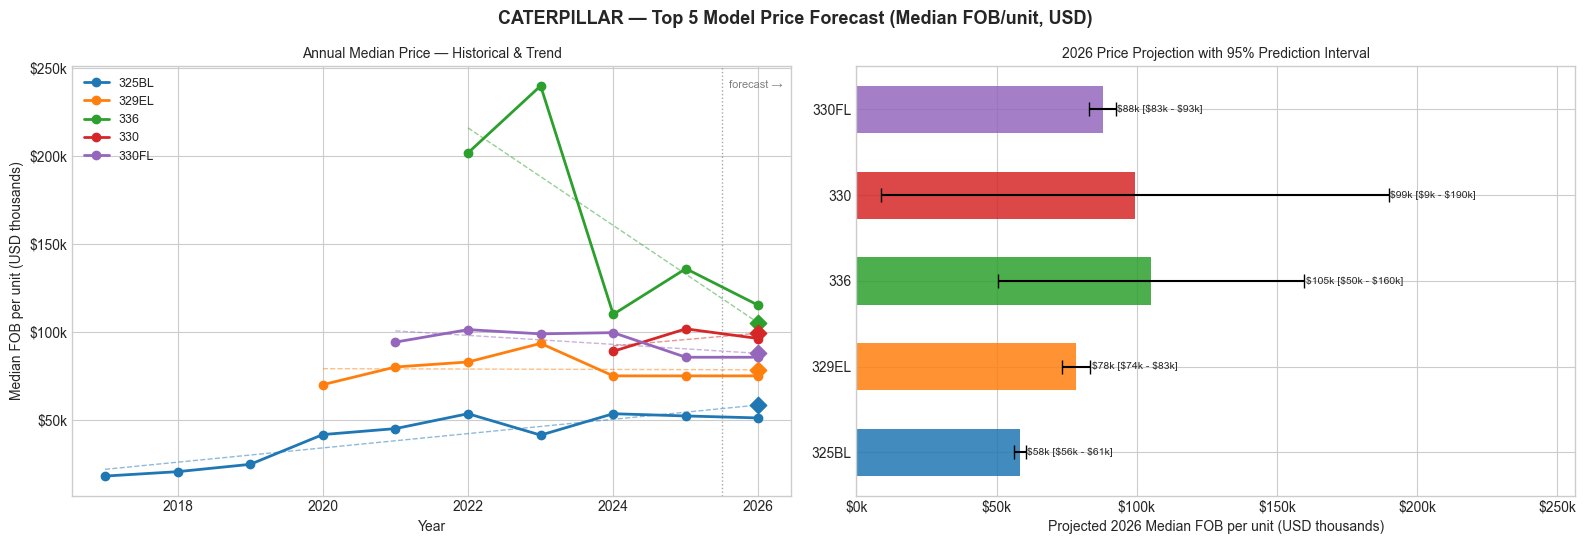

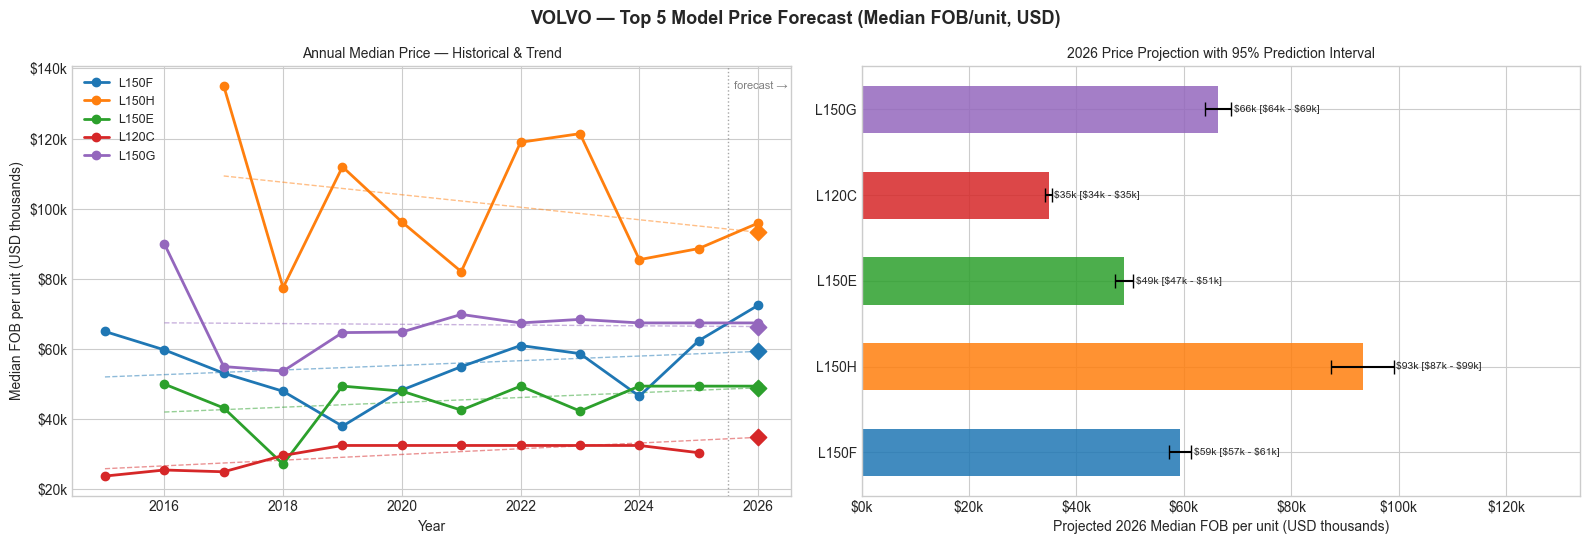


── PRICE FORECAST SUMMARY TABLE ────────────────────────────────────


In [88]:
# ── Machine Price Forecast: Top Caterpillar & Volvo Models ───────────────
# For each brand:
#   1. Select top 5 models by shipment count with ≥ 3 years of data
#   2. Build annual median FOB unit price series (median = robust to outliers)
#   3. Winsorise at 1st–99th percentile per model before aggregating
#   4. OLS linear trend → project 2026 price + 95% prediction interval
#   5. Two-panel figure: price trajectories (left) + 2026 bar comparison (right)
#   6. Summary table with price CAGR and projected 2026 price

from scipy.stats import linregress as _linreg, t as _t
import numpy as np

MIN_YEARS   = 3     # minimum distinct years required
N_MODELS    = 5     # models per brand
BRANDS      = {
    'CATERPILLAR': {'color': '#f4a261', 'accent': '#e76f51'},
    'VOLVO':       {'color': '#457b9d', 'accent': '#1d3557'},
}

# ── Helper: winsorise + annual median ────────────────────────────────────
def _annual_price(df, brand, model):
    sub = df[
        (df['MARCA_CLEAN'] == brand) &
        (df['MODELO'] == model) &
        (df['US$ FOB UNIT'] > 0)
    ]['US$ FOB UNIT'].copy()
    # Winsorise 1–99th percentile
    lo, hi = sub.quantile(0.01), sub.quantile(0.99)
    sub    = sub.clip(lo, hi)
    # Re-attach ANO and aggregate
    idx  = df.loc[sub.index, 'ANO']
    ann  = sub.groupby(idx).median()
    return ann.sort_index()

# ── Helper: OLS trend + prediction interval for 2026 ────────────────────
def _trend_forecast(ann_series):
    x = ann_series.index.values.astype(float)
    y = ann_series.values
    if len(x) < 2:
        return None
    slope, intercept, r, _, se = _linreg(x, y)
    proj    = intercept + slope * 2026
    # 95% PI: t_{n-2} × SE_pred
    n       = len(x)
    x_mean  = x.mean()
    ss_x    = ((x - x_mean) ** 2).sum()
    se_pred = se * np.sqrt(1 + 1/n + (2026 - x_mean)**2 / ss_x) if ss_x > 0 else se
    t_crit  = _t.ppf(0.975, df=max(n - 2, 1))
    margin  = t_crit * se_pred
    cagr    = ((y[-1] / y[0]) ** (1 / (n - 1)) - 1) * 100 if y[0] > 0 else 0
    return dict(slope=slope, intercept=intercept, proj=max(proj, 0),
                pi_lo=max(proj - margin, 0), pi_hi=proj + margin,
                r2=r**2, cagr=cagr, n=n)

# ── Select top models per brand ───────────────────────────────────────────
_df = df_units.copy()
_df['MODELO'] = _df['MODELO'].fillna('').str.strip()
_valid_mask   = (
    (_df['MODELO'] != '') &
    (~_df['MODELO'].str.upper().isin(['UNKNOWN'])) &
    (_df['US$ FOB UNIT'] > 0)
)

def _select_top(brand):
    sub  = _df[_valid_mask & (_df['MARCA_CLEAN'] == brand)]
    freq = (sub.groupby('MODELO')
               .agg(Count=('US$ FOB UNIT', 'count'),
                    Nyears=('ANO', lambda x: x.nunique()))
               .query(f'Nyears >= {MIN_YEARS}')
               .sort_values('Count', ascending=False)
               .head(N_MODELS))
    return freq.index.tolist()

# ── Main plot + table loop ────────────────────────────────────────────────
all_summary = []

for brand, style in BRANDS.items():
    models  = _select_top(brand)
    palette = plt.cm.tab10.colors

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 5.5))
    fig.suptitle(f'{brand} — Top {N_MODELS} Model Price Forecast (Median FOB/unit, USD)',
                 fontsize=13, fontweight='bold')

    proj_vals, proj_lo, proj_hi, model_labels = [], [], [], []

    for idx, model in enumerate(models):
        ann  = _annual_price(_df, brand, model)
        fc   = _trend_forecast(ann)
        if fc is None:
            continue

        col  = palette[idx]
        xs   = ann.index.values
        ys   = ann.values / 1e3   # → USD thousands

        # ── Left: price trajectories ──────────────────────────────────
        ax_l.plot(xs, ys, marker='o', lw=2, color=col, label=model, zorder=3)
        # Trend line to 2026
        _xl  = np.linspace(xs.min(), 2026, 200)
        _yl  = (fc['intercept'] + fc['slope'] * _xl) / 1e3
        ax_l.plot(_xl, _yl, lw=1, ls='--', color=col, alpha=0.5)
        # 2026 projected point
        ax_l.scatter([2026], [fc['proj'] / 1e3], marker='D',
                     s=70, color=col, zorder=5)

        proj_vals.append(fc['proj'] / 1e3)
        proj_lo.append(fc['pi_lo'] / 1e3)
        proj_hi.append(fc['pi_hi'] / 1e3)
        model_labels.append(model)

        all_summary.append({
            'Brand':           brand,
            'Model':           model,
            'Obs (years)':     fc['n'],
            'Median Price 2025': f"${ann.iloc[-1]/1e3:,.1f}k" if ann.index[-1] == 2025 else 'N/A',
            'Price CAGR':      f"{fc['cagr']:+.1f}%",
            'Proj. 2026 (USD)': f"${fc['proj']:,.0f}",
            'PI 95%':          f"[${fc['pi_lo']:,.0f} – ${fc['pi_hi']:,.0f}]",
            'R²':              f"{fc['r2']:.2f}",
        })

    # ── Left panel formatting ──────────────────────────────────────────
    ax_l.axvline(2025.5, color='gray', ls=':', lw=1, alpha=0.7)
    ax_l.text(2025.6, ax_l.get_ylim()[1] * 0.97, 'forecast →',
              fontsize=8, color='gray', va='top')
    ax_l.set_xlabel('Year')
    ax_l.set_ylabel('Median FOB per unit (USD thousands)')
    ax_l.set_title('Annual Median Price — Historical & Trend', fontsize=10)
    ax_l.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
    ax_l.legend(fontsize=9, loc='upper left')

    # ── Right panel: 2026 projected bar + PI whiskers ─────────────────
    _y_pos    = np.arange(len(model_labels))
    _bars     = ax_r.barh(_y_pos, proj_vals,
                           color=[palette[i] for i in range(len(model_labels))],
                           alpha=0.85, height=0.55)
    # Error bars (prediction interval)
    _err_lo   = [p - l for p, l in zip(proj_vals, proj_lo)]
    _err_hi   = [h - p for p, h in zip(proj_vals, proj_hi)]
    ax_r.errorbar(proj_vals, _y_pos,
                  xerr=[_err_lo, _err_hi],
                  fmt='none', color='black', capsize=5, lw=1.5)
    # Value labels
  # Change this section:
    for j, (val, lo_, hi_) in enumerate(zip(proj_vals, proj_lo, proj_hi)):
        ax_r.text(hi_ + 0.5, j,
                  f'${val:,.0f}k '  # Added a space here for readability
                  f'[${lo_:,.0f}k - ${hi_:,.0f}k]', # Ensure this line starts with f'
                  va='center', fontsize=7.5)

    ax_r.set_yticks(_y_pos)
    ax_r.set_yticklabels(model_labels, fontsize=10)
    ax_r.set_xlabel('Projected 2026 Median FOB per unit (USD thousands)')
    ax_r.set_title('2026 Price Projection with 95% Prediction Interval', fontsize=10)
    ax_r.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
    ax_r.set_xlim(0, max(proj_hi) * 1.35)

    plt.tight_layout()
    plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print("\n── PRICE FORECAST SUMMARY TABLE ────────────────────────────────────")
_df_summ = pd.DataFrame(all_summary).set_index(['Brand', 'Model'])
display(_df_summ.style.apply(
    lambda col: [
        'background-color: #fff3cd' if idx[0] == 'CATERPILLAR'
        else 'background-color: #d4edda'
        for idx in _df_summ.index
    ], axis=0
))


In [67]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

# ── Build price_ts ────────────────────────────────────────────────────────
df_master = df_units.copy()
df_gdp    = pd.read_csv('cleaned_gdp_peru.csv')
df_gdp['Date'] = pd.to_datetime(df_gdp['Date'])

df_master['Date'] = pd.to_datetime(
    df_master['ANO'].astype(str) + '-' + df_master['MES'].astype(str) + '-01'
)
cut_off   = pd.to_datetime('2025-12-31')
df_master = df_master[df_master['Date'] <= cut_off]
df_gdp    = df_gdp[df_gdp['Date'] <= cut_off]

monthly_price = df_master.groupby('Date')['US$ FOB'].mean().reset_index(name='Avg_FOB_Price')
price_ts = (
    pd.merge(monthly_price, df_gdp[['Date', 'PBI_Construccion']], on='Date', how='inner')
    .sort_values('Date')
    .set_index('Date')
)

# ── Quick stationarity check on Avg_FOB_Price ─────────────────────────────
# (PBI_Construccion already confirmed I(1) in the main stationarity cell above)
_adf_lv  = adfuller(price_ts['Avg_FOB_Price'].dropna(), autolag='AIC')
_adf_d1  = adfuller(price_ts['Avg_FOB_Price'].diff().dropna(), autolag='AIC')
_kpss_lv = kpss(price_ts['Avg_FOB_Price'].dropna(), regression='c', nlags='auto')
_kpss_d1 = kpss(price_ts['Avg_FOB_Price'].diff().dropna(), regression='c', nlags='auto')
print("Avg_FOB_Price stationarity")
print(f"  Level      ADF p={_adf_lv[1]:.4f}  KPSS p={_kpss_lv[1]:.4f}")
print(f"  First diff ADF p={_adf_d1[1]:.4f}  KPSS p={_kpss_d1[1]:.4f}")
_price_I1 = (_adf_lv[1] >= 0.05) and (_adf_d1[1] < 0.05)
print(f"  => {'I(1) confirmed' if _price_I1 else 'AMBIGUOUS — interpret Johansen with caution'}")

# ── Johansen cointegration test for price_ts ─────────────────────────────
print("\n--- Johansen Test: Avg_FOB_Price vs PBI_Construccion ---")
jres_p = coint_johansen(price_ts, det_order=0, k_ar_diff=1)
print(f"{'Hypothesis':<18} {'Trace':>10} {'cv 95%':>10}  Decision")
print("-" * 46)
_price_rank = 0
for _r in range(len(jres_p.lr1)):
    _tr  = jres_p.lr1[_r]
    _cv  = jres_p.cvt[_r, 1]
    _dec = "REJECT ✓" if _tr > _cv else "fail to reject"
    print(f"H0: rank <= {_r}    {_tr:>10.4f} {_cv:>10.4f}  {_dec}")
    if _tr > _cv:
        _price_rank += 1

_price_coint_rank = max(_price_rank, 1)
print(f"\n=> Cointegration rank = {_price_coint_rank}"
      f"{' (borderline — floored to 1)' if _price_rank == 0 else ''}")

# ── VECM for price elasticity ─────────────────────────────────────────────
vecm_p = VECM(price_ts, k_ar_diff=1,
              coint_rank=_price_coint_rank,
              deterministic='co').fit()
print("\n--- PRICE ELASTICITY: VECM Adjustment Coefficients ---")
print(vecm_p.summary().tables[1])


Avg_FOB_Price stationarity
  Level      ADF p=0.0000  KPSS p=0.1000
  First diff ADF p=0.0000  KPSS p=0.1000
  => AMBIGUOUS — interpret Johansen with caution

--- Johansen Test: Avg_FOB_Price vs PBI_Construccion ---
Hypothesis              Trace     cv 95%  Decision
----------------------------------------------
H0: rank <= 0       72.1203    15.4943  REJECT ✓
H0: rank <= 1       16.0722     3.8415  REJECT ✓

=> Cointegration rank = 2

--- PRICE ELASTICITY: VECM Adjustment Coefficients ---
Det. terms outside the coint. relation & lagged endog. parameters for equation PBI_Construccion
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  82.1428     19.537      4.205      0.000      43.852     120.434
L1.Avg_FOB_Price     9.809e-06   5.55e-05      0.177      0.860    -9.9e-05       0.000
L1.PBI_Construccion    -0.2837      0.090     -3.143     